In [93]:
from IPython.display import HTML, display

html = """
<style>
/* Background accent container */
.corp-accents {
    position: fixed;
    inset: 0;
    pointer-events: none;
    z-index: -1;
}

/* Accent blocks */
.accent {
    position: absolute;
    background: rgba(120, 120, 120, 0.10);
    border-radius: 6px;
}

/* Top */
.a1 { width: 140px; height: 2px; top: 25px; left: 40px; }
.a2 { width: 90px; height: 2px; top: 25px; right: 60px; }

/* Bottom */
.a3 { width: 120px; height: 2px; bottom: 30px; left: 50px; }
.a4 { width: 100px; height: 2px; bottom: 30px; right: 50px; }

/* Left vertical */
.a5 { width: 2px; height: 120px; top: 120px; left: 25px; }
.a6 { width: 2px; height: 90px; bottom: 120px; left: 25px; }

/* Right vertical */
.a7 { width: 2px; height: 110px; top: 140px; right: 25px; }
.a8 { width: 2px; height: 80px; bottom: 140px; right: 25px; }
</style>

<div class="corp-accents">
    <div class="accent a1"></div>
    <div class="accent a2"></div>
    <div class="accent a3"></div>
    <div class="accent a4"></div>
    <div class="accent a5"></div>
    <div class="accent a6"></div>
    <div class="accent a7"></div>
    <div class="accent a8"></div>
</div>
"""

display(HTML(html))

In [94]:
from IPython.display import HTML, display

html = """
    <link href="https://fonts.googleapis.com/css2?family=Roboto:wght@400;700&display=swap" rel="stylesheet">

    <link rel="stylesheet" href="custom.css">
    <script src="custom.js" defer></script>
    <style>
        div.jp-OutputPrompt.jp-OutputArea-prompt {
            display: none !important;
        }
    
        .jp-OutputPrompt {
            display: none !important;
        }

        .jp-Notebook-cell.celltag_remove_cell {
            display: none !important;
        }
    </style>

    """
    
display(HTML(html))

from IPython.display import HTML, Image, display

html = """

<div id="cover-page-container">
    <img id="cover-page-image" src="images/blue-bg.jpg" alt="Description of the image" />
    <div id="title-container">
        <h1>Ancient Heights Apartments</h1>
        <div id="meta-data-container">
            <div>February 5, 2026</div>
            <div>by Aaron Hardy</div>
        </div>
    </div>
    <div id="title-bar"></div>
</div>
"""

display(HTML(html))

# ANALYSIS OF APARTMENT PROPERTIES

## Analyst: Aaron Hardy

## Date: June 7, 2026

---

## Goal

1. Find the markets where rents are rising the fastest and rising the slowest
<!-- 2. Find the markets where renter demand is rising the fastest and rising the slowest
2. Find which markets have the highest SFR sales price per square foot
3. Find markets where apartment properties are likely to rise due to potential rental rate growth, growing renter demand and higher construction median sale price per square foot -->

## Data: Zillow

### ZORI

- URL: https://www.zillow.com/research/data/?msockid=09f1e4300f88632836b5f3550e666237
- Zillow Observed Rent Index (ZORI): A smoothed measure of the typical observed market rate rent across a given region. ZORI is a repeat-rent index that is weighted to the rental housing stock to ensure representativeness across the entire market, not just those homes currently listed for-rent. The index is dollar-denominated by computing the mean of listed rents that fall into the 35th to 65th percentile range for all homes and apartments in a given region, which is weighted to reflect the rental housing stock.
  ZORI is created for three different categories: All homes, Single Family Residences, and Multi-Family Residences. For more detailed information, you can refer to the ZORI methodology.

### Zillow Smoothing and Seasonality-Adjustments

Once the index is computed, it is smoothed using a three-month simple moving average. A seasonally adjusted series is available and calculated using a proprietary algorithm that is more robust to outlier events such as the 2020 pandemic.

<!-- ### ZORDI
https://www.zillow.com/research/data/?msockid=09f1e4300f88632836b5f3550e666237
Zillow Observed Renter Demand Index (ZORDI): A measure of the typical observed rental market engagement across a region. ZORDI tracks engagement on Zillow’s rental listings to proxy changes in rental demand. The metric is smoothed to remove volatility.
ZORDI is created for different categories including All homes, Single Family Residences, Condo and Multi-Family Residences at national and MSA levels.

### New Construction Median Sale Price Per Sqft
https://www.zillow.com/research/data/?msockid=09f1e4300f88632836b5f3550e666237
New Construction Median Sale Price Per Sqft: The median sale price divided by square footage calculated over all new construction homes across various geographies were sold during the month. -->

### City Populations

https://www.census.gov/data/tables/time-series/demo/popest/2020s-total-cities-and-towns.html


In [95]:
# ===============================
# STEP 1: LOAD DATA
# ===============================

import pandas as pd
import numpy as np
import duckdb

# small = pd.read_csv("data/raw/apartments_for_rent_classified_10K.csv")
# large = pd.read_csv("data/raw/apartments_for_rent_classified_10K.csv")
# Metro ZORI, multi-family, seasonally-adjusted, smoothed, monthly
zori_raw = pd.read_csv("data/raw/zillow/Metro_zori_uc_mfr_sm_month.csv", index_col=None)
#
zordi_raw_all = pd.read_csv("data/raw/zillow/Metro_zordi_uc_sfrcondomfr_month.csv")
#
zordi_raw_multifam = pd.read_csv("data/raw/zillow/Metro_zordi_uc_mfr_month.csv")
#
price_per_sqf_sfr_condo_raw = pd.read_csv(
    "data/raw/zillow/Metro_new_con_median_sale_price_per_sqft_uc_sfrcondo_month.csv"
)
# Census population estimates (released May 2026)
pop_raw = pd.read_csv("data/raw/census/cbsa-est2025-alldata.csv", encoding="latin1")

# print(zori.head(3))
# print(zordi_all.head(3))
# print(zordi_multifam.head(3))
# print(pop.head(3))

## 1. ZORI (Zillow Observed Rent Index)

No. of cities: 932


In [96]:
# ==========================
# STEP 2: Round index values
# ==========================
zori = zori_raw.round(0)

# =============================
# STEP 3: Pivot shape
# ==============================
zori = zori.melt(
    id_vars=["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"],
    var_name="Date",
    value_name="Zori",
)

# ============================
# STEP 4: Remove nulls
# ============================
zori.dropna(subset="Zori", inplace=True)
# print(zori[zori['Zori'].isna()])

# =============================
# STEP 5: Format Date
# =============================
# print(zori['Date'].dtype)
zori["Date"] = pd.to_datetime(zori["Date"], errors="coerce")

# print(zori['Date'].min())
# print(zori['Date'].max())
# print(zori['Date'].isna().sum())

# =============================
# STEP 6: Remove regions with short time series
# =============================

region_counts = zori["RegionName"].value_counts()
# print(region_counts['Cedar Rapids, IA'])
# print(zori[zori['RegionName'] == 'Cedar Rapids, IA'])
sufficient_data_regions = region_counts[region_counts >= 5 * 12 + 2].index

# print(zori.loc[zori['RegionName'] == 'Cedar Rapids, IA'].head(200))

zori = zori[zori["RegionName"].isin(sufficient_data_regions)]


# =============================
# STEP 6: Add CAGR
# =============================


def add_cagr(df, years):
    months = 12 * years
    df = df.sort_values(["RegionName", "Date"])

    df[f"CAGR_{years}yr"] = df.groupby("RegionName")["Zori"].transform(
        lambda x: ((x / x.shift(months)) ** (1 / years) - 1).round(3)
    )
    return df


zori = add_cagr(zori, 1)
zori = add_cagr(zori, 2)
zori = add_cagr(zori, 5)


def add_vol(df, years):
    months = 12 * years
    df["pct_chg"] = df.groupby("RegionName")["Zori"].pct_change()
    df = df.sort_values(["RegionName", "Date"])

    df[f"SD_{years}yr"] = df.groupby("RegionName")["pct_chg"].transform(
        lambda x: (x.rolling(months).std() * np.sqrt(12)).round(3)
    )
    return df


zori = add_vol(zori, 1)
zori = add_vol(zori, 2)
zori = add_vol(zori, 5)


# print(zori.dropna(subset=['CAGR_1yr', 'CAGR_2yr', 'CAGR_5yr']).head(10))

# =============================
# STEP _: Calculate growth rates
# =============================

# Calculate 3-month simple moving average of rental growth rates
# zori['SMA_Growth_3MO'] = (
#     zori.groupby('RegionName')['Growth_Rate'].transform(lambda x: x.rolling(window=3).mean())
# )

# =============================
# STEP 7: Filter out smaller regions (keep top 200 regions by population)
# =============================
zori = zori[zori["SizeRank"] <= 200]


# zori.nlargest(10, "CAGR_5yr")
# Rank of the percent growth within each month (1 = highest growth rate)
# Growth rate is the percent change in ZORI from the previous month for each region
# ZORI smoothed is itself a 3-month moving average of rental rates


# =============================
# STEP 8: Remove missing value rows
# =============================

zori = zori[~zori["CAGR_1yr"].isna()]

# =============================
# STEP _: Calculate Ranks
# =============================
# zori['Growth_Rank_CAGR_1yr'] = zori.groupby('Date')['CAGR_1yr'].rank(ascending=False, method='dense')
# zori['Growth_Rank_CAGR_2yr'] = zori.groupby('Date')['CAGR_2yr'].rank(ascending=False, method='dense')
# zori['Growth_Rank_CAGR_5yr'] = zori.groupby('Date')['CAGR_5yr'].rank(ascending=False, method='dense')


# =============================
# STEP 10: Remove Outliers
# =============================

TUKEY_FACTOR = 1.5
Q1 = zori["CAGR_1yr"].quantile(0.25)
Q3 = zori["CAGR_1yr"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - TUKEY_FACTOR * IQR
upper_limit = Q3 + TUKEY_FACTOR * IQR

# zori = zori.loc[(zori['CAGR_1yr'] < upper_limit) & zori['CAGR_1yr'] > lower_limit]
zori = zori.loc[zori["CAGR_1yr"].between(lower_limit, upper_limit)]


# =============================
# STEP 11: Subset the Data
# =============================
zori = (
    zori[
        [
            "RegionName",
            "Date",
            "Zori",
            "SizeRank",
            "CAGR_1yr",
            "CAGR_2yr",
            "CAGR_5yr",
            "SD_1yr",
            "SD_2yr",
            "SD_5yr",
        ]
    ]
    .sort_values(
        ["Date", "CAGR_1yr", "CAGR_2yr", "CAGR_5yr", "SD_1yr", "SD_2yr", "SD_5yr"],
        ascending=False,
    )
    .reset_index(drop=True)
)


# ===========================================
# STEP _: Estimate missing population values
# ===========================================
# An attempt to interpolate the missing populations resulted in extreme values that were double their verified numbers via Google search


# =============================
# STEP 9: Add Population Data
# =============================

# Select the MSA data
pop = pop_raw.loc[
    pop_raw["LSAD"] == "Metropolitan Statistical Area", ["NAME", "POPESTIMATE2025"]
]

#     NAME              POPESTIMATE2025
# 0   Abilene, TX       185429
# 4   Akron, OH         701780

merged = (
    zori.merge(pop, left_on="RegionName", right_on="NAME", how="left")
    .drop(columns=["NAME"])
    .rename(columns={"POPESTIMATE2025": "Population 2025"})
    .sort_values(["Date", "CAGR_1yr"], ascending=False)
)

# merged['Population 2025'] = merged['Population 2025'].fillna('Not specified')


# =================================================
# STEP 11: Select largest 300 markets (by MSA size)
# =================================================
# print(merged['SizeRank'].min())
# print(merged['SizeRank'].max())


from IPython.display import display

display(
    merged.head(10)
    .style.set_caption("""
    <div style='font-size:18px; font-weight:600;'>Which cities are leading rental rate growth?</div>
    <div style='font-size:13px; color:#888; margin-bottom: 2px;'>Rank movements over the last 18 months</div>
    """)
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [("caption-side", "top"), ("text-align", "left")],
            }
        ]
    )
    .format(
        {
            "Date": lambda x: x.strftime("%b %Y"),
            "Zori": "{:,.0f}",
            "CAGR_1yr": "{:.1%}",
            "CAGR_2yr": "{:.1%}",
            "CAGR_5yr": "{:.1%}",
            "SD_1yr": "{:.1%}",
            "SD_2yr": "{:.1%}",
            "SD_5yr": "{:.1%}",
            "Population 2025": lambda x: "-" if pd.isna(x) else f"{x:,.0f}",
        }
    )
    .hide(axis="index")
)

RegionName,Date,Zori,SizeRank,CAGR_1yr,CAGR_2yr,CAGR_5yr,SD_1yr,SD_2yr,SD_5yr,Population 2025
"Cedar Rapids, IA",Apr 2026,"1,014",179,12.9%,8.5%,6.2%,3.1%,4.2%,3.7%,"279,285"
"Evansville, IN",Apr 2026,"1,001",165,12.0%,9.7%,9.9%,8.5%,6.2%,5.3%,"273,786"
"Binghamton, NY",Apr 2026,"1,213",195,8.9%,7.1%,9.6%,5.8%,5.1%,5.8%,"243,189"
"Reno, NV",Apr 2026,"1,783",113,8.9%,5.9%,4.3%,3.3%,3.2%,3.6%,"578,734"
"Gulfport, MS",Apr 2026,"1,206",133,8.3%,6.6%,8.2%,4.1%,4.3%,4.9%,-
"Salisbury, MD",Apr 2026,"1,767",134,6.5%,6.1%,6.5%,4.2%,3.6%,5.9%,"131,872"
"Urban Honolulu, HI",Apr 2026,"2,393",55,6.4%,5.4%,5.2%,3.1%,2.3%,2.6%,"988,703"
"San Francisco, CA",Apr 2026,"2,991",12,6.2%,4.9%,4.1%,1.5%,1.5%,2.2%,-
"Rockford, IL",Apr 2026,"1,057",153,6.0%,6.8%,7.2%,3.1%,3.1%,2.9%,"337,242"
"Virginia Beach, VA",Apr 2026,"1,702",38,5.8%,4.9%,5.9%,1.1%,1.5%,3.1%,-


## Analysis

The analysis was conducted on the top 200 of 713 metro regions by population that have time series covering at least five years. The top 200 metro areas are likely to face lower volatility in rent trends.

The top 5 metro areas by 1-year average rent growth include:

1. Cedar Rapids, IA
2. Evansville, IN
3. Binghamton, NY
4. Reno, NV
5. Gulfport, MS

Cedar Rapids, IA experienced the fastest 1-year compound at 12.9%, followed closely by Evansville, IN (12.0%). These metro areas were home to approximately 280,000 and 240,000 residents, respectively. Cedar Rapids experienced the highest growth rate and most stable upward trend (declining standard deviation of rental growth rates). Evansville, IN experienced the second highest growth rate accompanied by a increasingly volatile trend (rising volatility of rental growth rates).


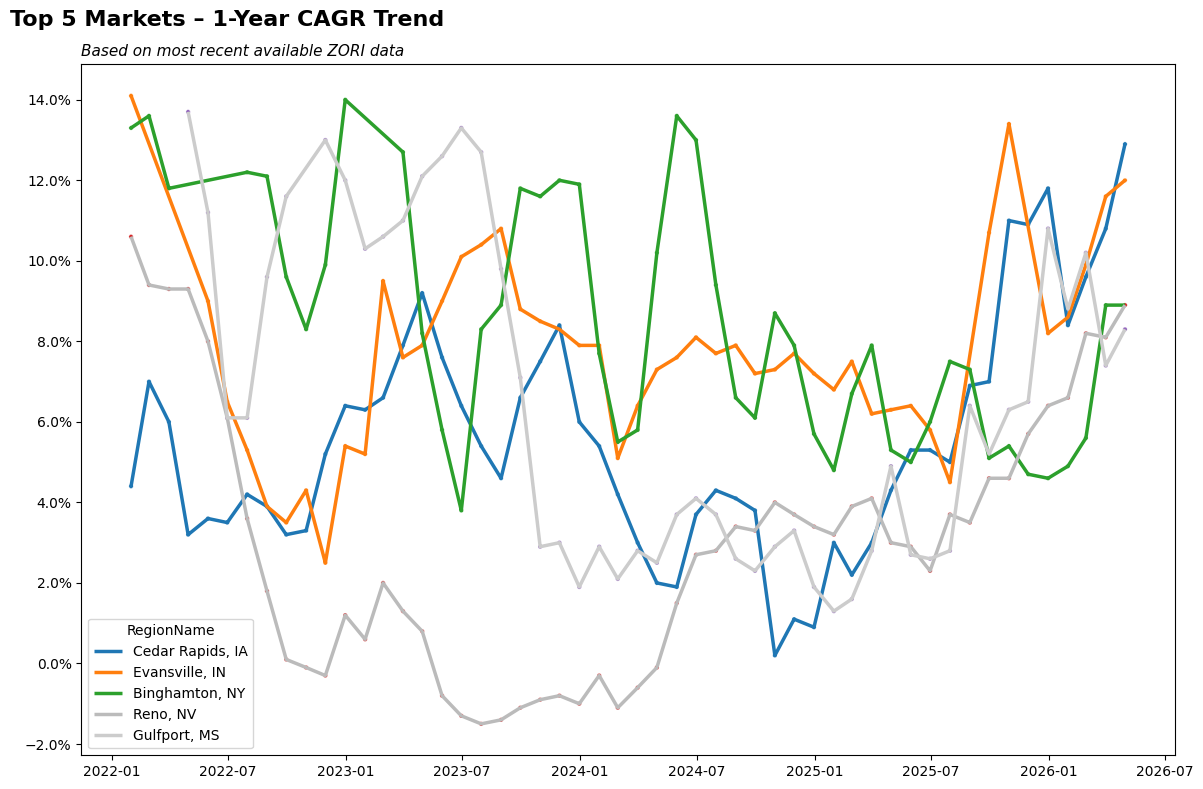

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.ticker import PercentFormatter

# state_avg = (
#     zori.groupby(['StateName', 'Date'])['Growth_Rank']
#         .mean()
#         .reset_index()
# )
top_5_regions = merged.loc[merged["Date"] == merged["Date"].max()].nlargest(
    5, "CAGR_1yr"
)["RegionName"]


subset = merged.loc[merged["RegionName"].isin(top_5_regions)]
subset = subset[subset["Date"] >= "2022-01-01"]


# print(state_avg.head())
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=subset, x="Date", y="CAGR_1yr", hue="RegionName", legend=False, s=10
)

# Title + subtitle
plt.suptitle(
    "Top 5 Markets – 1-Year CAGR Trend",
    fontsize=16,
    fontweight="bold",
    x=0.0,          # left align
    ha='left'
)

plt.title(
    "Based on most recent available ZORI data",
    fontsize=11,
    style="italic",
    x=0.0,          # left align
    ha='left'
)


# plt.gca().invert_yaxis()
# plt.title("CAGR_1yr")

# Format y-axis as percent
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
# (Assumes CAGR_1yr is stored as decimal, e.g., 0.045 = 4.5%)

# plt.xlabel("Date")

# subset = zori.loc[(zori['Date'] > '2023-01-01') & (zori['Growth_Rank'] <= 5)]

# plt.figure(figsize=(14,7))
# sns.scatterplot(data=subset, x='Date', y='Growth_Rank', hue='RegionName', s=80)
# Pick your 5 regions
r1, r2, r3, r4, r5 = top_5_regions.tolist()

# Define custom colors (two low‑hue / desaturated)
custom_colors = {
    r1: "#1f77b4",      # normal blue
    r2: "#ff7f0e",      # normal orange
    r3: "#2ca02c",      # normal green
    r4: "#bbbbbb",      # light gray (low hue)
    r5: "#cccccc",      # lighter gray (low hue)
}

sns.lineplot(
    data=subset,
    x="Date",
    y="CAGR_1yr",
    hue="RegionName",
    palette=custom_colors,
    linewidth=2.5,
    dashes=(1,0)
)

plt.xlabel("")
plt.ylabel("")
plt.tight_layout()

# plt.gca().invert_yaxis()

# for _, row in subset.iterrows():
#     plt.text(row['Date'], row['CAGR_1yr'], row['RegionName'], fontsize=8)

plt.show()

## Analysis

The 1-year CAGR chart shows the rental rate growth trend since 2022. Although Cedar Rapids, IA has the current highest 1-year CAGR, Evansville, IN and Binghamton, NY experienced rental rate growth consistently above their peers in the 5-region comparison set. 